# 05 — Misaligned AGN: Radio-to-Gamma Conversion Chain

Misaligned AGN (radio galaxies viewed off-axis) contribute to the gamma-ray
background through a multi-step conversion: Willott et al. (2001) 151 MHz
radio LF $\to$ Inoue (2011) frequency scaling $\to$ Lara et al. (2004)
core-total decomposition $\to$ Di Mauro et al. (2014) radio-to-gamma
correlation. The Willott RLF uses an archaic $H_0=50$ empty-universe
cosmology, requiring a volume correction factor $\eta(z)$.

**References:**

1. `docs/equations.md` §5 (Eqs. 5.7–5.11)
2. Di Mauro+ (2014)
3. Willott+ (2001)

In [ ]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [ ]:
from hi_gamma_xcorr import astro_sources as astro

\
## 1. Willott Two-Component Radio LF (Eq. 5.7)

$$\rho_r(L_{151}, z) = \rho_l + \rho_h$$

Low-power component: Schechter-like with $(1+z)^{k_L}$ evolution.
High-power component: Gaussian decline beyond $z_h^*=2.03$.

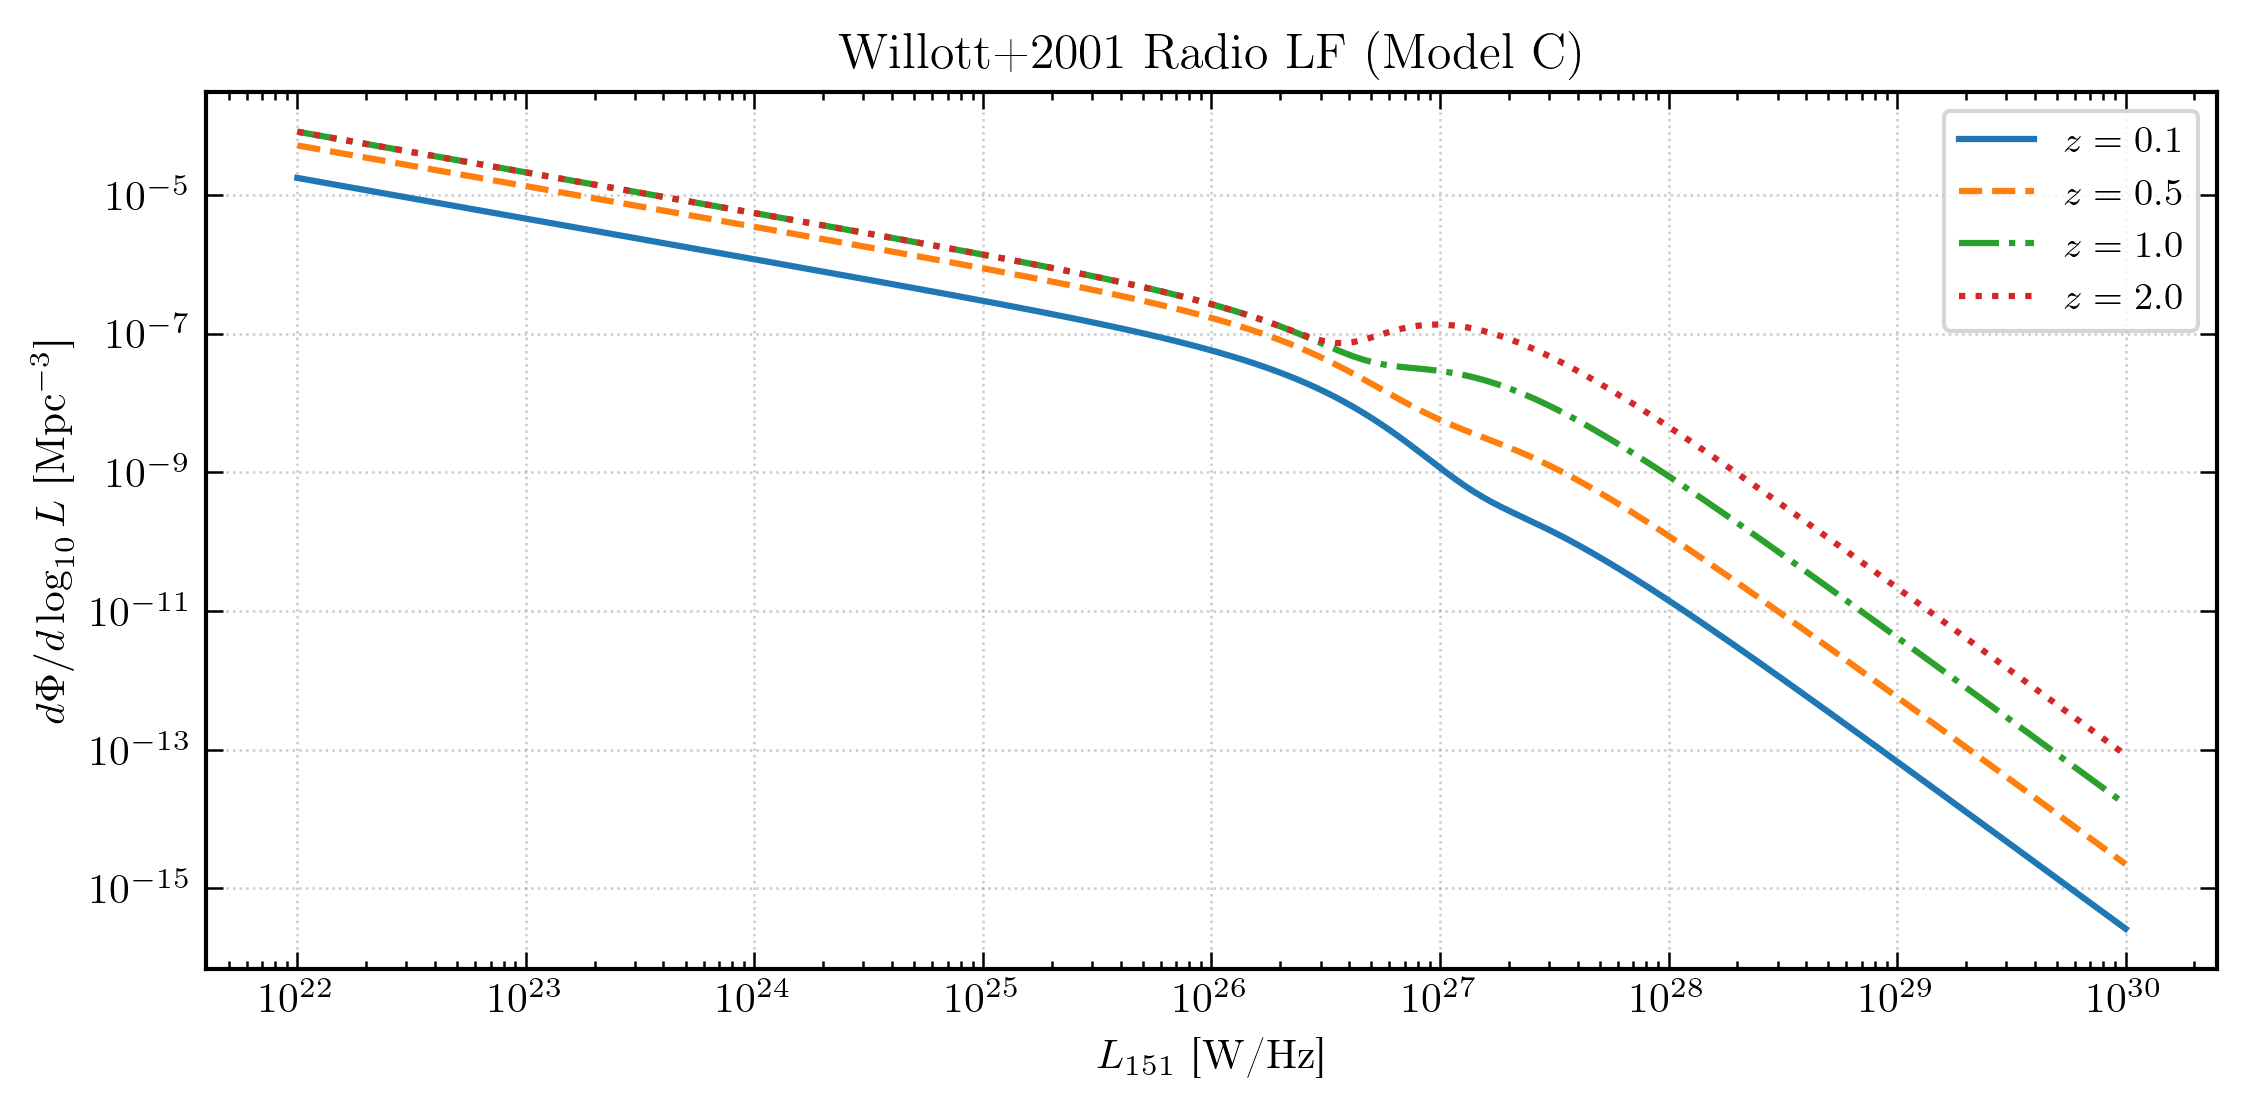

In [ ]:
L151 = np.logspace(22, 30, 200)
fig, ax = sty.textwidth_figure(8)
for z, ls in [(0.1, '-'), (0.5, '--'), (1.0, '-.'), (2.0, ':')]:
    rho = np.array([astro._willott_rlf(L, z) for L in L151])
    ax.loglog(L151, rho, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$L_{151}$ [W/Hz]')
ax.set_ylabel(r'$d\Phi/d\log_{10}L$ [Mpc$^{-3}$]')
ax.set_title('Willott+2001 Radio LF (Model C)'); ax.legend(); fig.tight_layout()

\
## 2. Volume Correction $\eta(z)$ (Di Mauro Eq. 18)

Converts from the Willott $H_0=50$, $\Omega_M=0$ cosmology to Planck 2018.

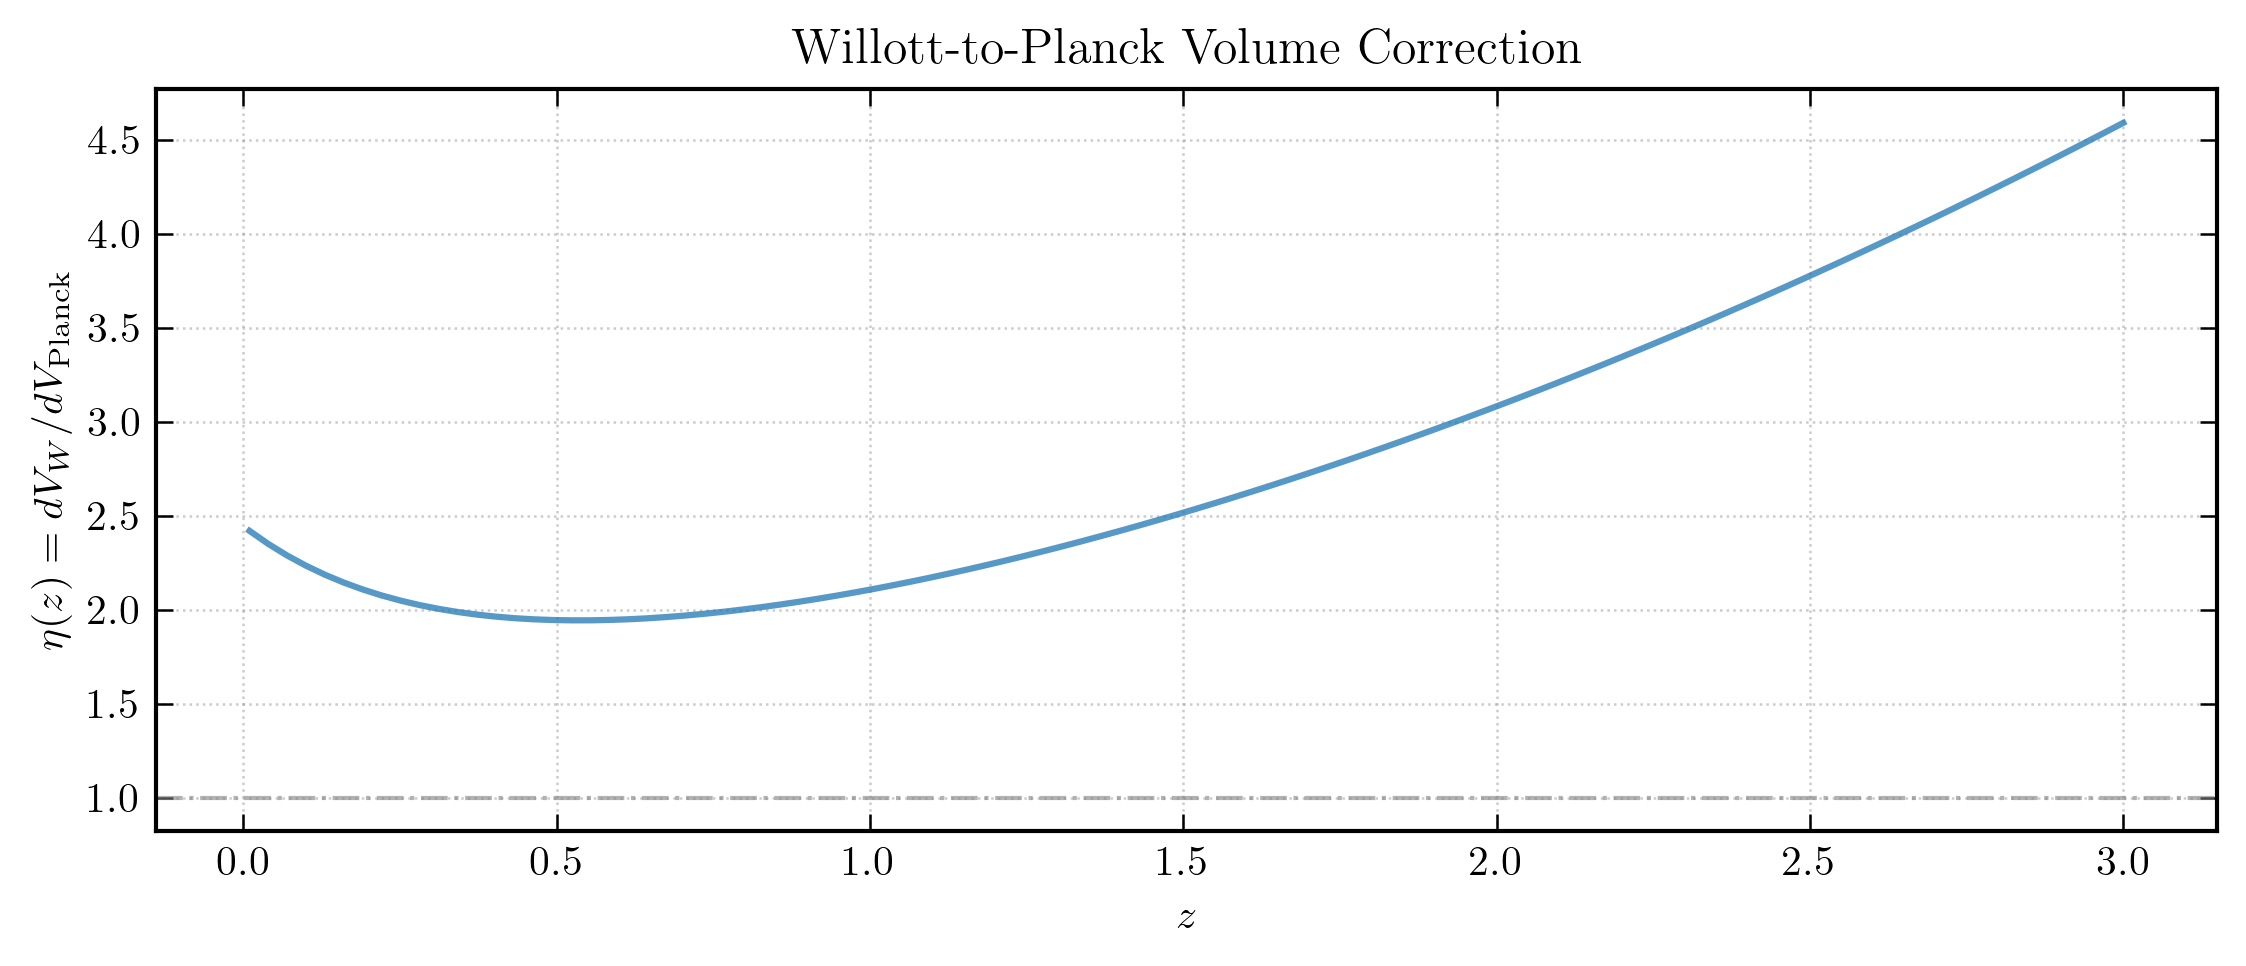

In [ ]:
z_eta = np.linspace(0.01, 3.0, 100)
eta = np.array([astro._willott_volume_correction(z) for z in z_eta])
fig, ax = sty.textwidth_figure(7)
ax.plot(z_eta, eta, **sty.FIT_STYLE)
ax.set_xlabel('$z$'); ax.set_ylabel(r'$\eta(z) = dV_W/dV_\mathrm{Planck}$')
ax.set_title('Willott-to-Planck Volume Correction'); sty.unity_line(ax); fig.tight_layout()

\
## 3. Radio$\to$Gamma Conversion Chain (Eqs. 5.8–5.10)

$$L_\gamma \xrightarrow{\text{Di Mauro}} \nu L_{\nu,\text{core}}^{5\text{GHz}}
\xrightarrow{\text{Lara}} L_\text{tot}^{1.4\text{GHz}}
\xrightarrow{\text{Inoue}} L_{151}$$

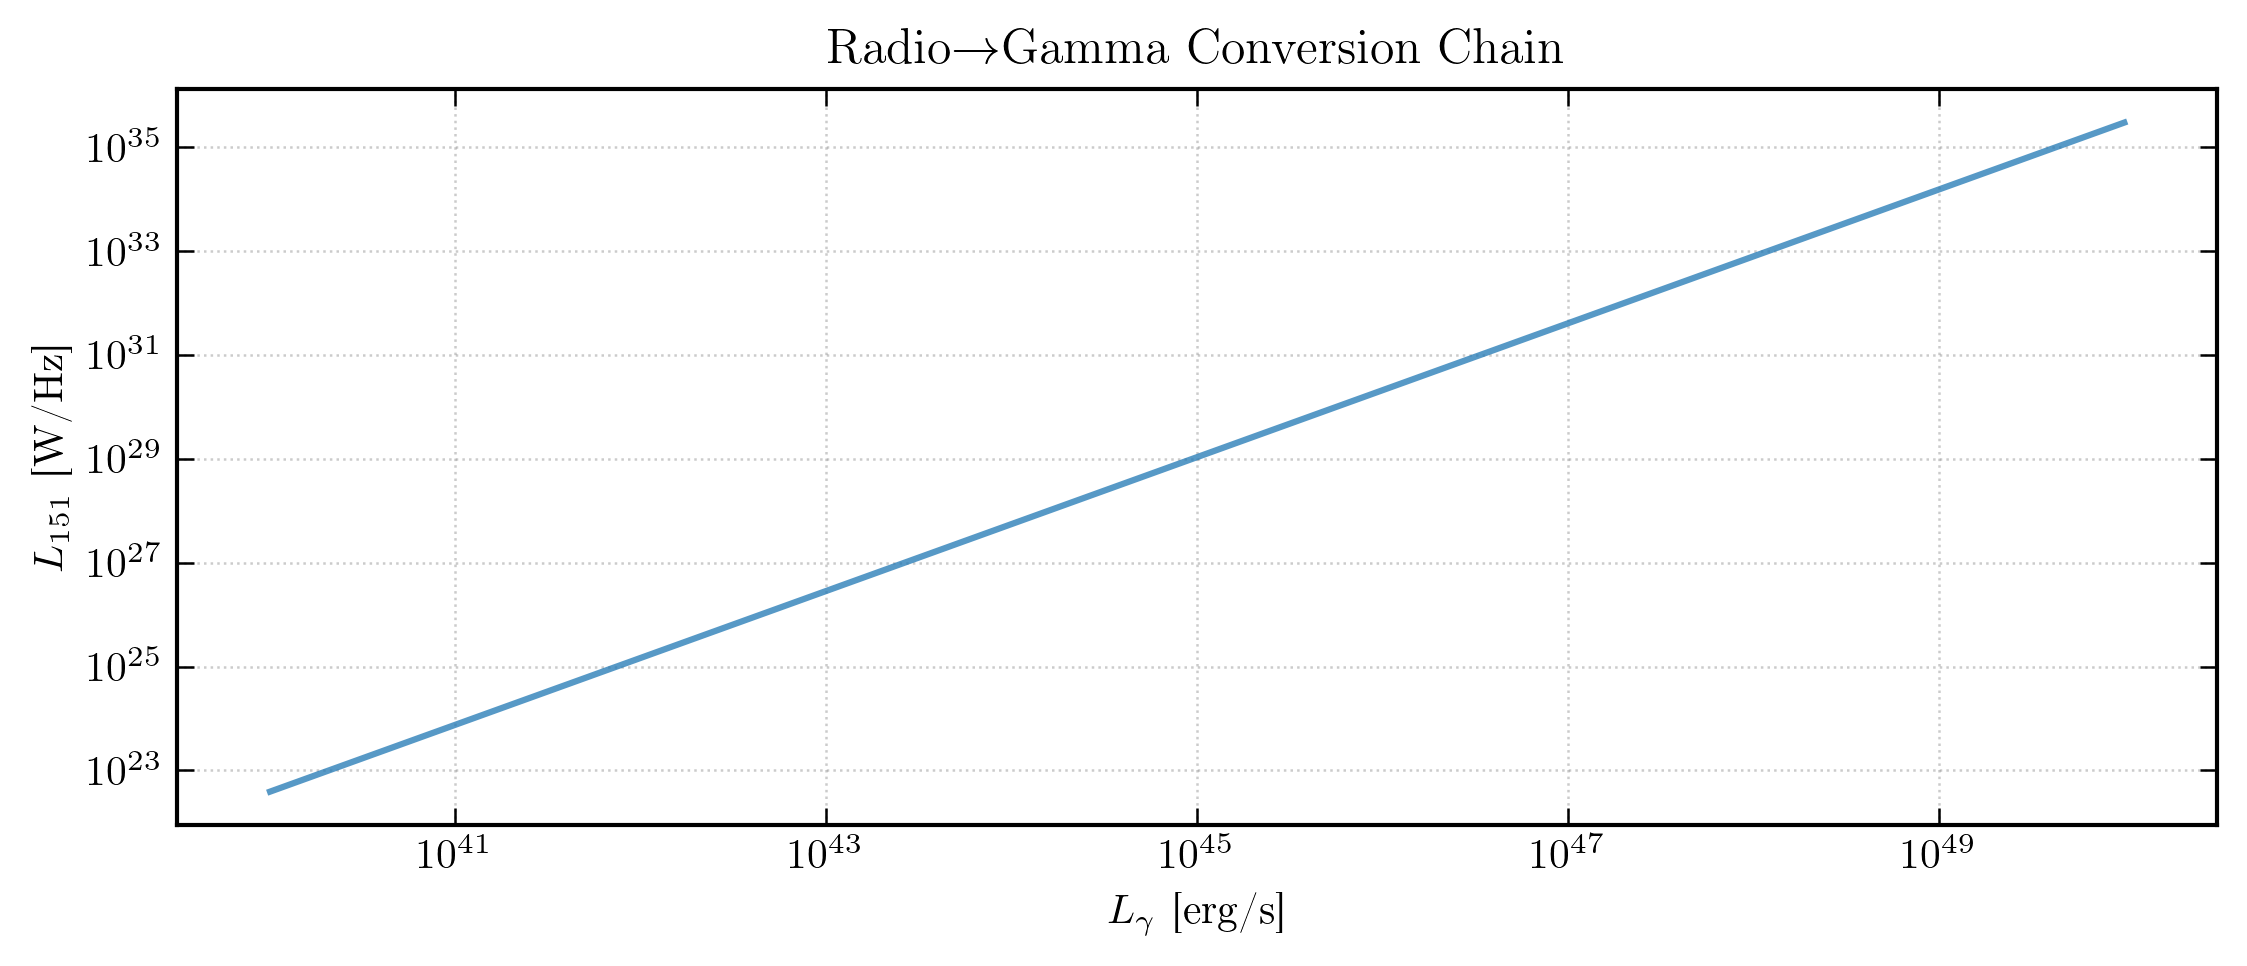

In [ ]:
Lgamma = np.logspace(40, 50, 100)
L151_arr = np.array([astro._L151_from_Lgamma(L)[0] for L in Lgamma])

fig, ax = sty.textwidth_figure(7)
ax.loglog(Lgamma, L151_arr, **sty.FIT_STYLE)
ax.set_xlabel(r'$L_\gamma$ [erg/s]'); ax.set_ylabel(r'$L_{151}$ [W/Hz]')
ax.set_title(r'Radio$\to$Gamma Conversion Chain'); fig.tight_layout()

## 4. mAGN GLF (Eq. 5.11) and Comparison

The full mAGN GLF combines the Willott RLF, volume correction, radio-to-gamma
chain, and a K-correction factor:

$$\phi_\gamma = \frac{k\,\eta(z)}{(1+z)^{2-\Gamma}}\,
\frac{\rho_r}{\ln 10\,L_{151}}\,
\left\lvert\frac{dL_{151}}{dL_\gamma}\right\rvert,\qquad
k = 3.05,\;\Gamma = 2.37$$

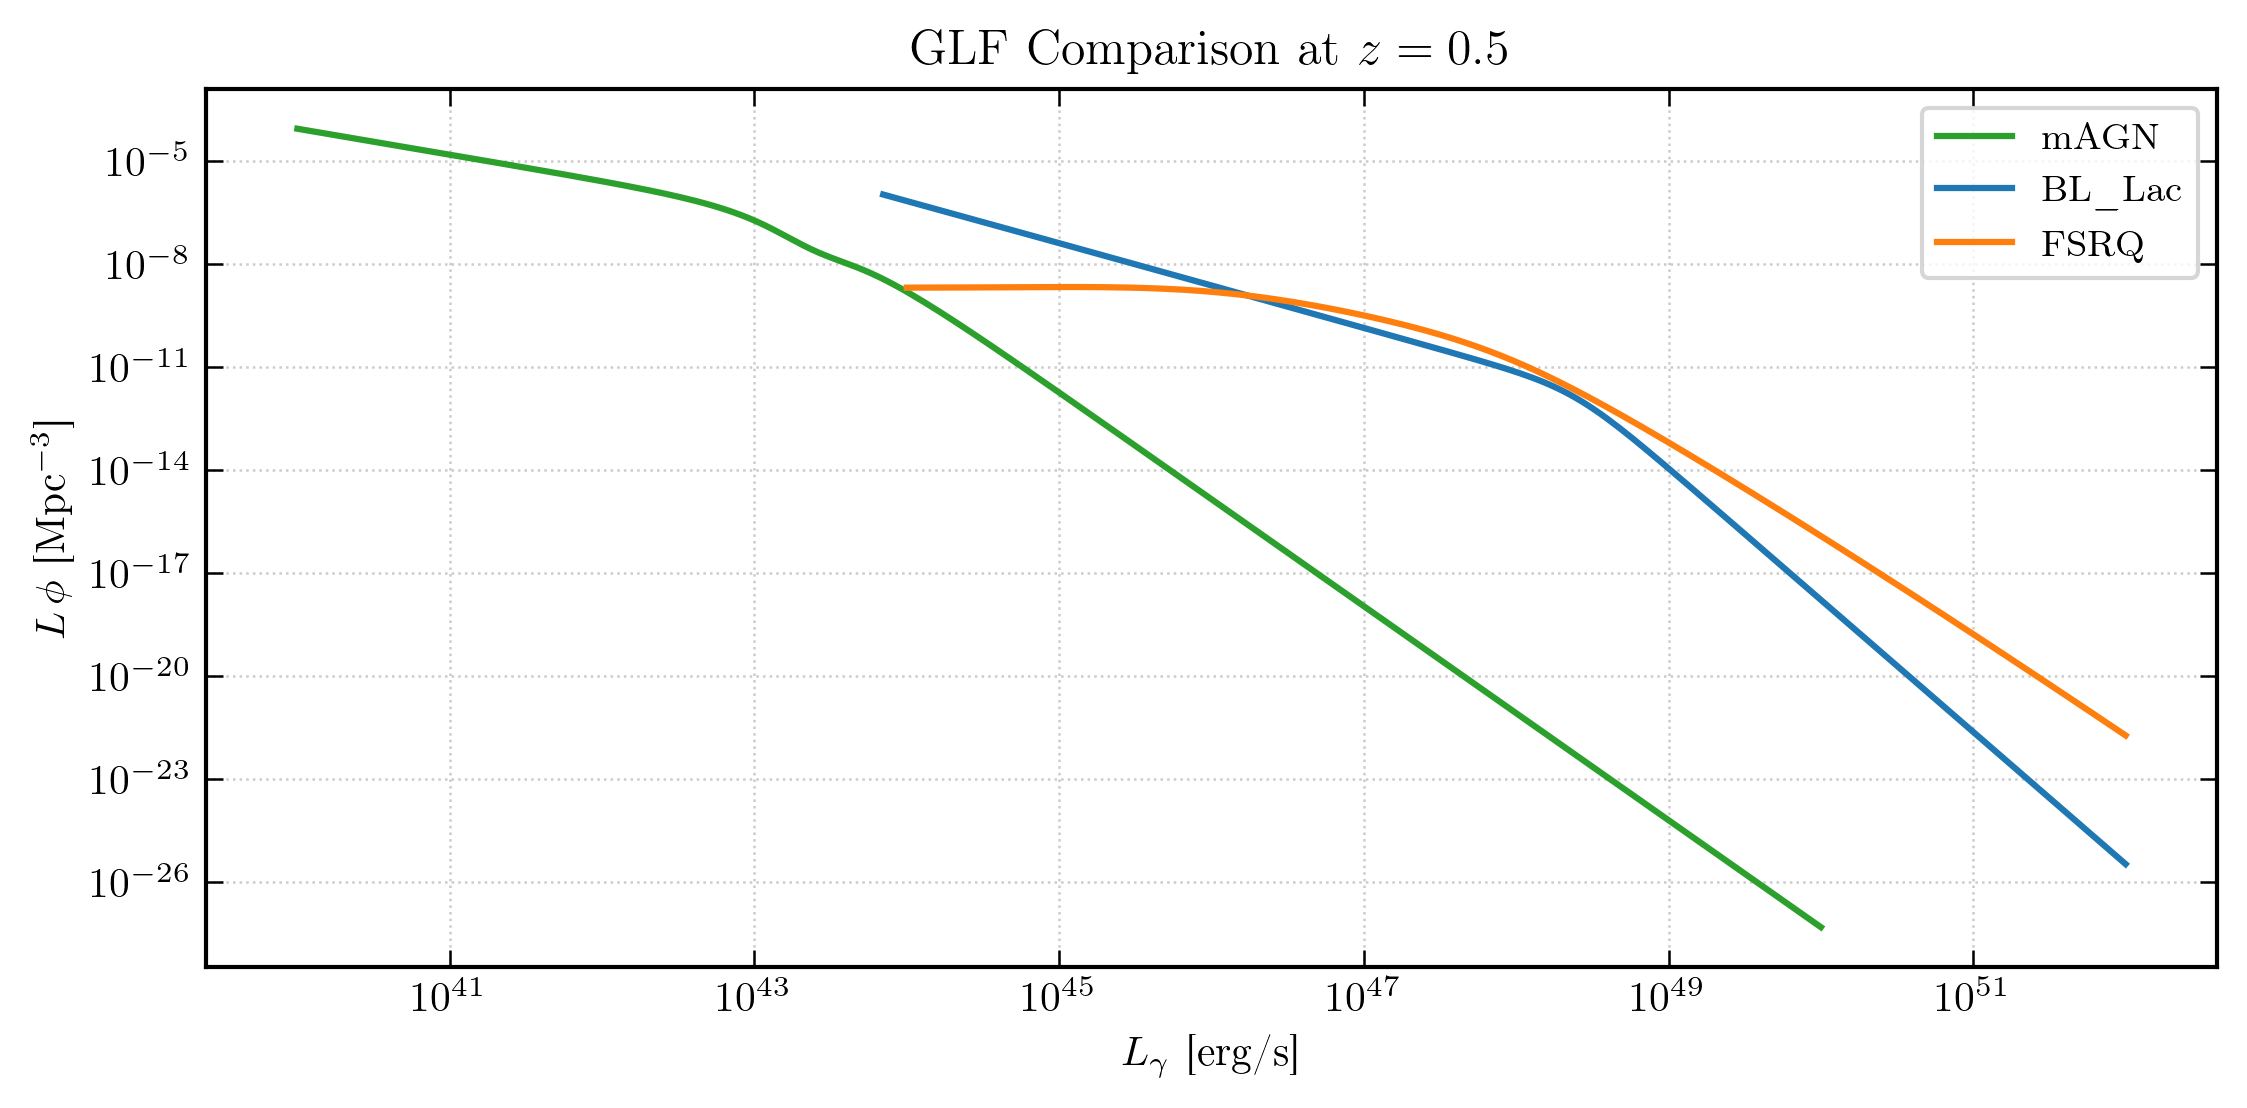

In [ ]:
L_arr = np.logspace(40, 50, 200)
fig, ax = sty.textwidth_figure(8)
for src, color in [('mAGN', 'C2'), ('BL_Lac', 'C0'), ('FSRQ', 'C1')]:
    L_range = np.logspace(np.log10(cfg.ASTRO_SOURCES[src]['L_min']),
                          np.log10(cfg.ASTRO_SOURCES[src]['L_max']), 200)
    phi = np.array([astro.glf(L, 0.5, src) for L in L_range])
    ax.loglog(L_range, L_range * phi, color=color, lw=sty.LW_STANDARD, label=src)
ax.set_xlabel(r'$L_\gamma$ [erg/s]'); ax.set_ylabel(r'$L\,\phi$ [Mpc$^{-3}$]')
ax.set_title('GLF Comparison at $z=0.5$'); ax.legend(); fig.tight_layout()

## 5. Window Function (Eq. 5.5) and Intensity

EBL attenuation applied at observed energy (**D14**).

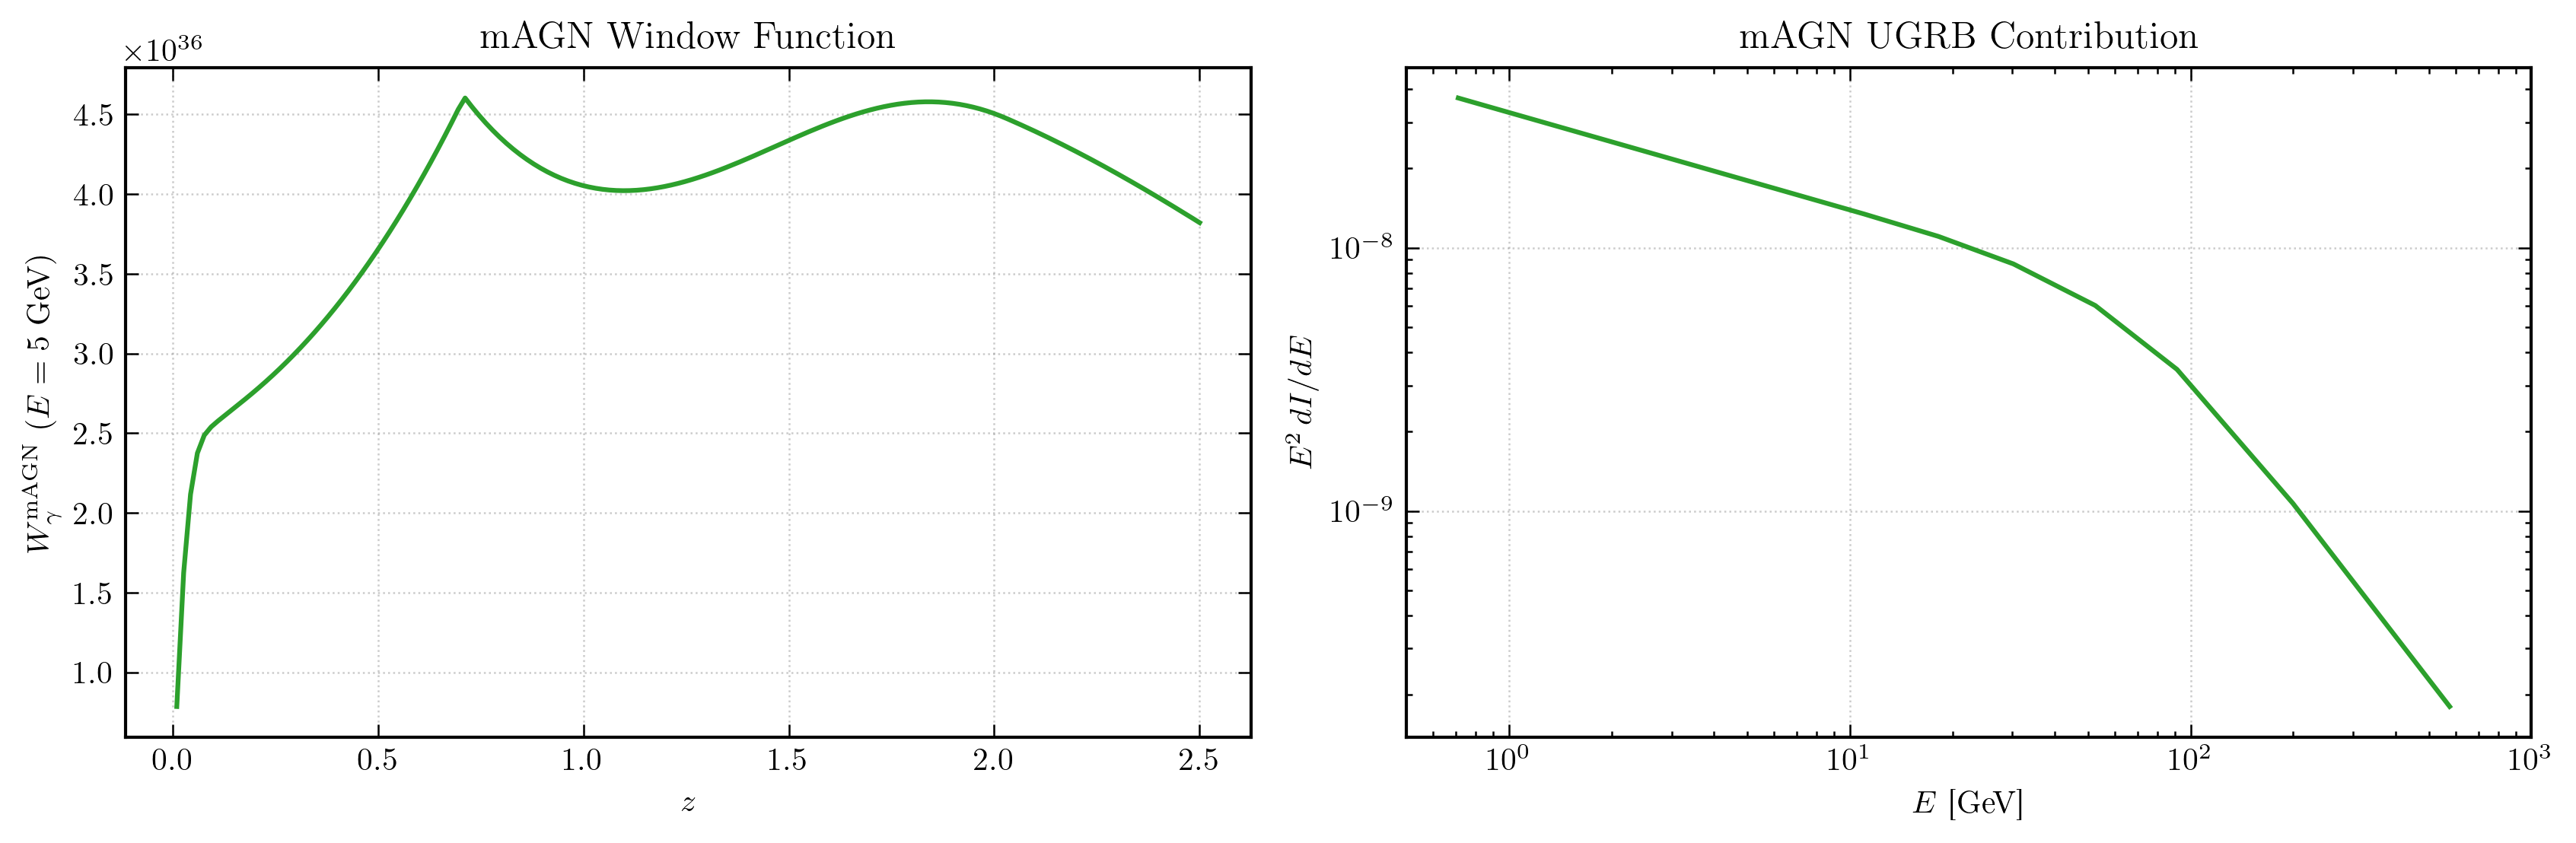

In [ ]:
z_w = np.linspace(0.01, 2.5, 150)
E_arr = cfg.FERMI_E_B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))
W = np.array([astro.W_gamma_astro(5.0, z, 'mAGN') for z in z_w])
ax1.plot(z_w, W, 'C2', lw=sty.LW_STANDARD)
ax1.set_xlabel('$z$'); ax1.set_ylabel(r'$W_\gamma^\mathrm{mAGN}$ ($E=5$ GeV)')
ax1.set_title('mAGN Window Function')

I = np.array([astro.mean_intensity(E, 'mAGN') for E in E_arr])
ax2.loglog(E_arr, E_arr**2 * I, 'C2', lw=sty.LW_STANDARD)
ax2.set_xlabel('$E$ [GeV]'); ax2.set_ylabel(r'$E^2\,dI/dE$')
ax2.set_title('mAGN UGRB Contribution'); ax2.set_xlim(0.5, 1000)
fig.tight_layout()